# House prices classiofication

In [134]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve, accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Loading and preparing the dataset

In [135]:
df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [136]:
PRICE_BINS = [0, 150000, 250000, np.inf]
PRICE_LABELS = ['Budget', 'MidRange', 'Premium']

df['PriceCategory'] = pd.cut(df['SalePrice'], bins=PRICE_BINS, labels=PRICE_LABELS)

TARGET = 'PriceCategory'
CLASSES = PRICE_LABELS

print("Price segment boundaries:", PRICE_BINS)
print("\nDistribution of objects by class:")
print(df[TARGET].value_counts().reindex(CLASSES))

Price segment boundaries: [0, 150000, 250000, inf]

Distribution of objects by class:
PriceCategory
Budget      619
MidRange    624
Premium     217
Name: count, dtype: int64


## 2. Exploratory data analysis

In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   str     
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   str     
 6   Alley          91 non-null     str     
 7   LotShape       1460 non-null   str     
 8   LandContour    1460 non-null   str     
 9   Utilities      1460 non-null   str     
 10  LotConfig      1460 non-null   str     
 11  LandSlope      1460 non-null   str     
 12  Neighborhood   1460 non-null   str     
 13  Condition1     1460 non-null   str     
 14  Condition2     1460 non-null   str     
 15  BldgType       1460 non-null   str     
 16  HouseStyle     1460 non-null   str     
 17  OverallQual    1460 non-null   int64   
 18 

In [138]:
missing = df.isna().sum()[lambda s: s > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct,
})
missing_table

,n_missing,pct_missing
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [139]:
n_classes = df[TARGET].nunique()

class_counts = df[TARGET].value_counts().reindex(CLASSES)
class_share = (class_counts / len(df) * 100).round(1)
class_table = pd.DataFrame({'count': class_counts, 'share_%': class_share})
display(class_table)


,count,share_%
PriceCategory,,
Budget,619,42.4
MidRange,624,42.7
Premium,217,14.9


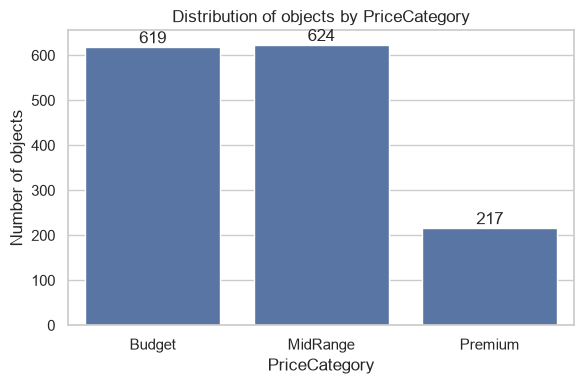

In [140]:
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, order=CLASSES)
plt.ylabel('Number of objects')
plt.title('Distribution of objects by PriceCategory')
for i, v in enumerate(class_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 3. Feature matrix X and target vector y

In [141]:
X = df.drop(columns=['SalePrice', TARGET, 'Id'], errors='ignore').copy()
y = df[TARGET].copy()

X['MSSubClass'] = X['MSSubClass'].astype(str)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=[str]).columns.tolist()

print(f"X: {X.shape}, y: {y.shape}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Numeric features: {len(numeric_cols)}")

X: (1460, 79), y: (1460,)
Categorical features: 44
Numeric features: 35


## 4. Splitting into train, validation, and test sets

In [142]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval)

print(f"X_train: {X_train.shape} ({len(X_train)/len(X):.0%})")
print(f"X_val:   {X_val.shape} ({len(X_val)/len(X):.0%})")
print(f"X_test:  {X_test.shape} ({len(X_test)/len(X):.0%})")

prop_table = pd.DataFrame({
    'full': y.value_counts(normalize=True).reindex(CLASSES) * 100,
    'train': y_train.value_counts(normalize=True).reindex(CLASSES) * 100,
    'val': y_val.value_counts(normalize=True).reindex(CLASSES) * 100,
    'test': y_test.value_counts(normalize=True).reindex(CLASSES) * 100,
}).round(1)
prop_table

X_train: (876, 79) (60%)
X_val:   (292, 79) (20%)
X_test:  (292, 79) (20%)


,full,train,val,test
PriceCategory,,,,
Budget,42.4,42.4,42.5,42.5
MidRange,42.7,42.7,42.8,42.8
Premium,14.9,15.0,14.7,14.7


## 5. Handling missing values, encoding, and feature scaling

In [143]:
none_means_absence = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 
       'GarageType', 'GarageCond', 'GarageFinish', 'GarageQual', 'BsmtFinType2', 
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1']


def build_preprocessor(X_fit_raw):
    Xf = X_fit_raw.copy()
    for col in none_means_absence:
       Xf[col] = Xf[col].fillna('None')
    
    cat_cols = Xf.select_dtypes(include=[str]).columns.tolist()
    num_cols = Xf.select_dtypes(include=[np.number]).columns.tolist()

    remaining_cat = [c for c in cat_cols if Xf[c].isna().any()]
    remaining_num = [c for c in num_cols if Xf[c].isna().any()]

    cat_imputer = SimpleImputer(strategy='most_frequent')
    if remaining_cat:
        cat_imputer.fit(Xf[remaining_cat])
        Xf[remaining_cat] = cat_imputer.transform(Xf[remaining_cat])

    num_imputer = SimpleImputer(strategy='median')
    if remaining_num:
        num_imputer.fit(Xf[remaining_num])
        Xf[remaining_num] = num_imputer.transform(Xf[remaining_num])

    iqr_bounds = {}
    for c in num_cols:
        q1, q3 = Xf[c].quantile(0.25), Xf[c].quantile(0.75)
        iqr = q3 - q1
        iqr_bounds[c] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        Xf[c] = Xf[c].clip(lower=iqr_bounds[c][0], upper=iqr_bounds[c][1])

        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        ohe.fit(Xf[cat_cols])

        scaler = StandardScaler()
        scaler.fit(Xf[num_cols])


    return dict(cat_cols=cat_cols, num_cols=num_cols, 
                remaining_cat=remaining_cat, remaining_num=remaining_num, 
                cat_imputer=cat_imputer, num_imputer=num_imputer,
                iqr_bounds=iqr_bounds, ohe=ohe, scaler=scaler)


def apply_preprocessor(X_raw, prep, scale=True):
    Xr = X_raw.copy()
    for col in none_means_absence:
        Xr[col] = Xr[col].fillna('None')

    if prep['remaining_cat']:
        Xr[prep['remaining_cat']] = prep['cat_imputer'].transform(Xr[prep['remaining_cat']])
    if prep['remaining_num']:
        Xr[prep['remaining_num']] = prep['num_imputer'].transform(Xr[prep['remaining_num']])

    for c in prep['num_cols']:
        lo, hi = prep['iqr_bounds'][c]
        Xr[c] = Xr[c].clip(lower=lo, upper=hi)

    X_cat = pd.DataFrame(
        prep['ohe'].transform(Xr[prep['cat_cols']]),
        columns=prep['ohe'].get_feature_names_out(prep['cat_cols']),
        index=Xr.index
    )
    if scale:
        X_num = pd.DataFrame(
            prep['scaler'].transform(Xr[prep['num_cols']]),
            columns=prep['num_cols'],
            index=Xr.index
        )
    else:
        X_num = Xr[prep['num_cols']].reset_index(drop=True)
        X_num.index = Xr.index
    
    return pd.concat([X_num, X_cat], axis=1)

In [144]:
prep = build_preprocessor(X_train)

X_train_final = apply_preprocessor(X_train, prep).reset_index(drop=True)
X_val_final = apply_preprocessor(X_val, prep).reset_index(drop=True)
X_test_final = apply_preprocessor(X_test, prep).reset_index(drop=True)

y_train_final = y_train.reset_index(drop=True)
y_val_final = y_val.reset_index(drop=True)
y_test_final = y_test.reset_index(drop=True)

print(f"X_train_final: {X_train_final.shape}")
print(f"X_val_final:   {X_val_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")

X_train_final: (876, 304)
X_val_final:   (292, 304)
X_test_final:  (292, 304)


In [145]:
print('Numerical features before scaling (train), mean / std:')
display(X_train[prep['num_cols']].agg(['mean', 'std']).T.head())

print('After standardization (train), mean / std:')
display(X_train_final[prep['num_cols']].agg(['mean', 'std']).T.head())

Numerical features before scaling (train), mean / std:


,mean,std
LotFrontage,71.047420,25.317492
LotArea,10595.855023,10219.993453
OverallQual,6.113014,1.349629
OverallCond,5.638128,1.114213
YearBuilt,1971.107306,29.968324


After standardization (train), mean / std:


,mean,std
LotFrontage,1.764190e-16,1.000571
LotArea,9.733462e-17,1.000571
OverallQual,2.169751e-16,1.000571
OverallCond,-1.095014e-16,1.000571
YearBuilt,-6.529531e-16,1.000571


In [146]:
X_train_unscaled = apply_preprocessor(X_train, prep, scale=False).reset_index(drop=True)
X_val_unscaled = apply_preprocessor(X_val, prep, scale=False).reset_index(drop=True)

## 6–7. Logistic Regression

In [147]:
def evaluate_classifier(model, X_eval, y_eval, classes=CLASSES):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)

    class_order = list(model.classes_)
    col_idx = [class_order.index(c) for c in classes]
    y_proba_ordered = y_proba[:, col_idx]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_eval, y_pred, labels=classes, average='macro', zero_division=0
    )
    roc_auc = roc_auc_score(y_eval, y_proba_ordered, multi_class='ovr', average='macro', labels=classes)
    acc = accuracy_score(y_eval, y_pred)
    cm = confusion_matrix(y_eval, y_pred, labels=classes)


    return {'Precision': precision, 'Recall': recall, 'F1-score': f1, 
            'ROC-AUC': roc_auc, 'Accuracy': acc}, cm, y_pred, y_proba_ordered


In [148]:
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_final, y_train_final)

lr_val_metrics, lr_val_cm, lr_val_pred, lr_val_proba = evaluate_classifier(log_reg, X_val_final, y_val_final)
pd.Series(lr_val_metrics).to_frame('validation')

,validation
Precision,0.870080
Recall,0.873187
F1-score,0.871397
ROC-AUC,0.964509
Accuracy,0.876712


              precision    recall  f1-score   support

      Budget       0.92      0.89      0.91       124
    MidRange       0.84      0.87      0.86       125
     Premium       0.84      0.86      0.85        43

    accuracy                           0.88       292
   macro avg       0.87      0.87      0.87       292
weighted avg       0.88      0.88      0.88       292



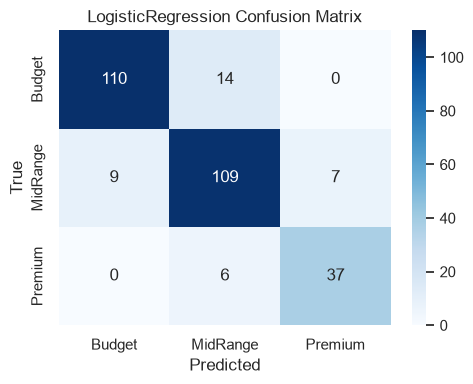

In [149]:
print(classification_report(y_val_final, lr_val_pred, labels=CLASSES, zero_division=0))

plt.figure(figsize=(5,4))
sns.heatmap(lr_val_cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LogisticRegression Confusion Matrix')
plt.tight_layout()
plt.show()

## 8. k-Nearest Neighbors

In [150]:
k_values = [3, 5, 7, 9, 11, 15, 21, 31, 41]

knn_results = []
knn_models = {}
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_final, y_train_final)
    knn_models[k] = model
    m, _, _, _ = evaluate_classifier(model, X_val_final, y_val_final)
    m['k'] = k
    knn_results.append(m)

knn_results_df = pd.DataFrame(knn_results)[['k', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'Accuracy']]
knn_results_df

,k,Precision,Recall,F1-score,ROC-AUC,Accuracy
0,3,0.858150,0.831825,0.843386,0.932641,0.856164
1,5,0.868221,0.803506,0.827093,0.954582,0.845890
2,7,0.879814,0.816279,0.840407,0.953498,0.849315
3,9,0.877140,0.821633,0.843213,0.958091,0.856164
4,11,0.886843,0.824365,0.847899,0.957019,0.859589
5,15,0.883968,0.829741,0.850533,0.960229,0.866438
6,21,0.898040,0.827031,0.853126,0.960575,0.863014
7,31,0.891414,0.808839,0.837347,0.962790,0.852740
8,41,0.886146,0.803506,0.831994,0.960936,0.845890


In [151]:
best_k = int(knn_results_df.loc[knn_results_df['F1-score'].idxmax(), 'k'])
print(f"Selected (best by F1-score on validation) value of k: {best_k}")

knn_best = knn_models[best_k]
knn_val_metrics, knn_val_cm, knn_val_pred, knn_val_proba = evaluate_classifier(knn_best, X_val_final, y_val_final)
pd.Series(knn_val_metrics).to_frame('validation')

Selected (best by F1-score on validation) value of k: 21


,validation
Precision,0.898040
Recall,0.827031
F1-score,0.853126
ROC-AUC,0.960575
Accuracy,0.863014


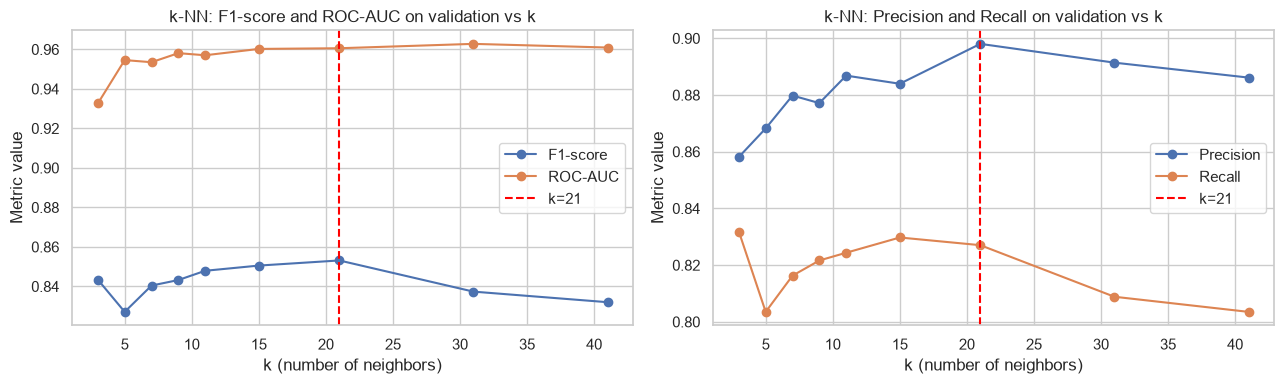

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(knn_results_df['k'], knn_results_df['F1-score'], marker='o', label='F1-score')
axes[0].plot(knn_results_df['k'], knn_results_df['ROC-AUC'], marker='o', label='ROC-AUC')
axes[0].axvline(best_k, color='red', linestyle='--', label=f'k={best_k}')
axes[0].set_xlabel('k (number of neighbors)')
axes[0].set_ylabel('Metric value')
axes[0].set_title('k-NN: F1-score and ROC-AUC on validation vs k')
axes[0].legend()

axes[1].plot(knn_results_df['k'], knn_results_df['Precision'], marker='o', label='Precision')
axes[1].plot(knn_results_df['k'], knn_results_df['Recall'], marker='o', label='Recall')
axes[1].axvline(best_k, color='red', linestyle='--', label=f'k={best_k}')
axes[1].set_xlabel('k (number of neighbors)')
axes[1].set_ylabel('Metric value')
axes[1].set_title('k-NN: Precision and Recall on validation vs k')
axes[1].legend()


plt.tight_layout()
plt.show()

## 9. SVM

### 9.1 SVM with linear kernel

In [153]:
C_values_linear = [0.001, 0.01, 0.1, 1, 10, 100]

svm_linear_results = []
svm_linear_models = {}
for C in C_values_linear:
    model = CalibratedClassifierCV(SVC(kernel='linear', C=C, random_state=RANDOM_STATE), ensemble=False)
    model.fit(X_train_final, y_train_final)
    svm_linear_models[C] = model
    m, _, _, _ = evaluate_classifier(model, X_val_final, y_val_final)
    m['C'] = C
    svm_linear_results.append(m)

svm_linear_df = pd.DataFrame(svm_linear_results)[['C', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'Accuracy']]
svm_linear_df

,C,Precision,Recall,F1-score,ROC-AUC,Accuracy
0,0.001,0.874825,0.739050,0.769546,0.960071,0.821918
1,0.010,0.912146,0.892188,0.901201,0.965323,0.907534
2,0.100,0.885231,0.896713,0.890410,0.959160,0.893836
3,1.000,0.865665,0.862392,0.862892,0.955283,0.863014
4,10.000,0.811883,0.822306,0.816369,0.940436,0.811644
5,100.000,0.808677,0.822306,0.814452,0.939525,0.811644


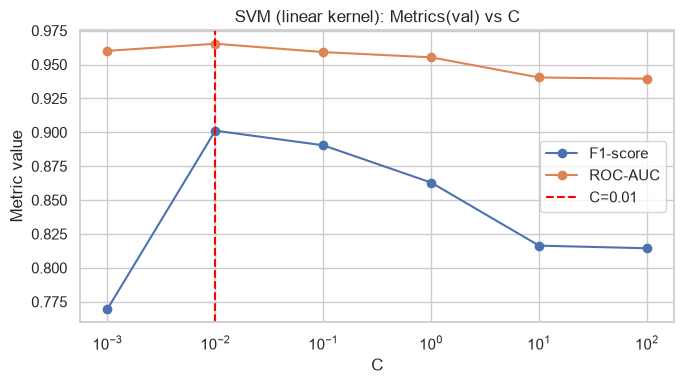

In [154]:
best_C_linear = svm_linear_df.loc[svm_linear_df['F1-score'].idxmax(), 'C']

plt.figure(figsize=(7,4))
plt.plot(svm_linear_df['C'], svm_linear_df['F1-score'], marker='o', label='F1-score')
plt.plot(svm_linear_df['C'], svm_linear_df['ROC-AUC'], marker='o', label='ROC-AUC')
plt.axvline(best_C_linear, color='red', linestyle='--', label=f'C={best_C_linear}')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Metric value')
plt.title('SVM (linear kernel): Metrics(val) vs C')
plt.legend()
plt.tight_layout()
plt.show()

### 9.2 SVM with RBF-kernel

In [155]:
C_values_rbf = [0.1, 1, 10, 100]
gamma_values_rbf = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

svm_rbf_results = []
svm_rbf_models = {}
for C in C_values_rbf:
    for gamma in gamma_values_rbf:
        model = CalibratedClassifierCV(SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_STATE), ensemble=False)
        model.fit(X_train_final, y_train_final)
        svm_rbf_models[(C, gamma)] = model
        m, _, _, _ = evaluate_classifier(model, X_val_final, y_val_final)
        m['C'] = C
        m['gamma'] = gamma
        svm_rbf_results.append(m)

svm_rbf_df = pd.DataFrame(svm_rbf_results)[['C', 'gamma', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'Accuracy']]
svm_rbf_df.sort_values('F1-score', ascending=False)

,C,gamma,Precision,Recall,F1-score,ROC-AUC,Accuracy
14,10.0,0.001,0.907323,0.891897,0.898920,0.964358,0.900685
6,1.0,scale,0.909964,0.884415,0.895515,0.974190,0.904110
9,1.0,0.01,0.910779,0.873974,0.889355,0.971881,0.897260
18,100.0,scale,0.882670,0.886294,0.884322,0.964308,0.886986
13,10.0,auto,0.887214,0.881187,0.883758,0.962508,0.886986
7,1.0,auto,0.903945,0.863599,0.880493,0.970939,0.890411
12,10.0,scale,0.870502,0.878273,0.874140,0.963680,0.876712
15,10.0,0.01,0.863987,0.875606,0.869387,0.959310,0.873288
21,100.0,0.01,0.865099,0.872918,0.868762,0.959010,0.869863
20,100.0,0.001,0.857727,0.867832,0.862140,0.952157,0.869863


Best RBF SVM configuration: C=10.0, gamma=0.001


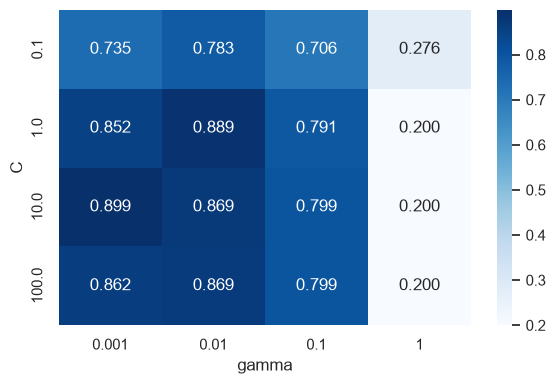

gamma,auto,scale
C,,
0.1,0.825834,0.807037
1.0,0.880493,0.895515
10.0,0.883758,0.874140
100.0,0.853897,0.884322


In [156]:
best_row = svm_rbf_df.loc[svm_rbf_df['F1-score'].idxmax()]
best_C_rbf, best_gamma_rbf = best_row['C'], best_row['gamma']
print(f"Best RBF SVM configuration: C={best_C_rbf}, gamma={best_gamma_rbf}")

pivot_numeric = svm_rbf_df[svm_rbf_df['gamma'].apply(lambda g: isinstance(g, (int, float)))].pivot(index='C', columns='gamma', values='F1-score')
plt.figure(figsize=(6, 4))
sns.heatmap(pivot_numeric, annot=True, fmt='.3f', cmap='Blues')
plt.title('')
plt.tight_layout()
plt.show()

svm_rbf_df[svm_rbf_df['gamma'].isin(['scale', 'auto'])].pivot(index='C', columns='gamma', values='F1-score')

In [157]:
svm_linear_best_row = svm_linear_df.loc[svm_linear_df['F1-score'].idxmax()]

if svm_linear_best_row['F1-score'] >= best_row['F1-score']:
    svm_best_kernel = 'linear'
    svm_best_params = {'C': best_C_linear}
    svm_best = svm_linear_models[best_C_linear]
    print(f"Selected SVM with linear kernel, C={best_C_linear} (F1={svm_linear_best_row['F1-score']:.4f})")
else:
    svm_best_kernel = 'rbf'
    svm_best_params = {'C': best_C_rbf, 'gamma': best_gamma_rbf}
    svm_best = svm_rbf_models[(best_C_rbf, best_gamma_rbf)]
    print(f"Selected SVM with RBF kernel, C={best_C_rbf}, gamma={best_gamma_rbf} (F1={best_row['F1-score']:.4f})")


svm_val_metrics, svm_val_cm, svm_val_pred, svm_val_proba = evaluate_classifier(svm_best, X_val_final, y_val_final)
pd.Series(svm_val_metrics).to_frame('validation')


Selected SVM with linear kernel, C=0.01 (F1=0.9012)


,validation
Precision,0.912146
Recall,0.892188
F1-score,0.901201
ROC-AUC,0.965323
Accuracy,0.907534


## 10. Confusion matrix

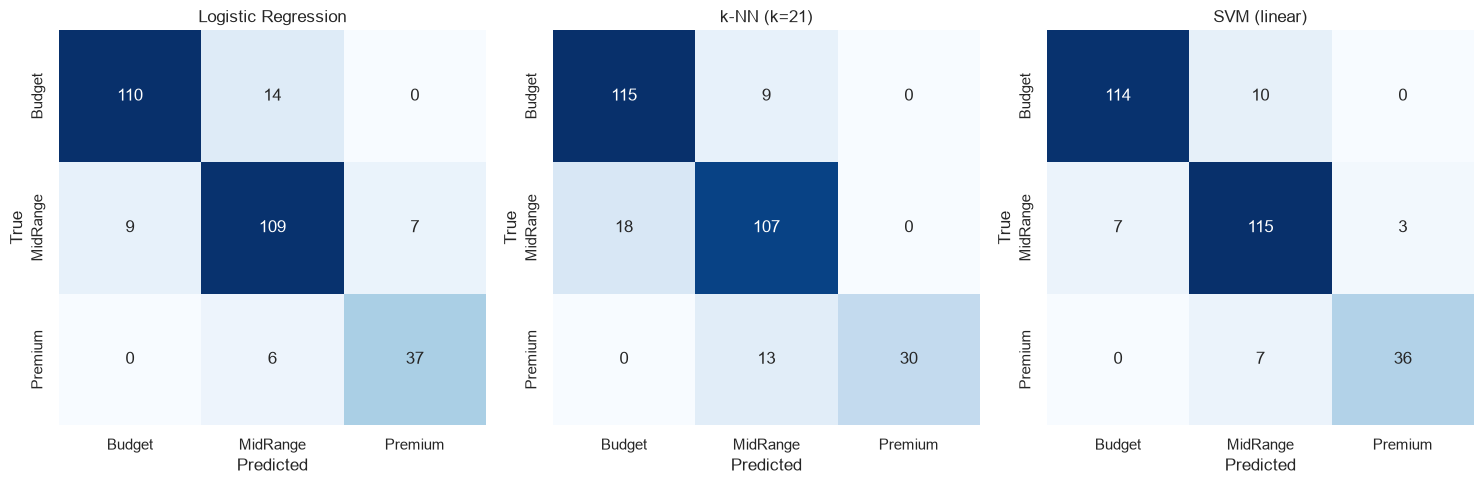

In [158]:
models_val = {
    'Logistic Regression': (lr_val_cm, lr_val_metrics),
    f'k-NN (k={best_k})': (knn_val_cm, knn_val_metrics),
    f'SVM ({svm_best_kernel})': (svm_val_cm, svm_val_metrics),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, (cm, _)) in zip(axes, models_val.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [159]:
for name, (cm, _) in models_val.items():
    print(f"--- {name} ---")
    cm_df = pd.DataFrame(cm, index=[f'true_{c}' for c in CLASSES], columns=[f'pred_{c}' for c in CLASSES])
    per_class_recall = np.diag(cm) / cm.sum(axis=1)
    for i, c in enumerate(CLASSES):
        print(f"  Class {c}: correct {cm[i, i]} of {cm[i].sum()} (recall={per_class_recall[i]:.2%});\n "
              f"\t\tmost common confusion: {CLASSES[np.argsort(-cm[i])[1]] if len(CLASSES) > 1 else '-'} "
              f"({cm[i][np.argsort(-cm[i])[1]]} cases)" if cm[i].sum() > cm[i,i] else
              f"  Class {c}: all {cm[i,i]} objects classified correctly")
    print()

--- Logistic Regression ---
  Class Budget: correct 110 of 124 (recall=88.71%);
 		most common confusion: MidRange (14 cases)
  Class MidRange: correct 109 of 125 (recall=87.20%);
 		most common confusion: Budget (9 cases)
  Class Premium: correct 37 of 43 (recall=86.05%);
 		most common confusion: MidRange (6 cases)

--- k-NN (k=21) ---
  Class Budget: correct 115 of 124 (recall=92.74%);
 		most common confusion: MidRange (9 cases)
  Class MidRange: correct 107 of 125 (recall=85.60%);
 		most common confusion: Budget (18 cases)
  Class Premium: correct 30 of 43 (recall=69.77%);
 		most common confusion: MidRange (13 cases)

--- SVM (linear) ---
  Class Budget: correct 114 of 124 (recall=91.94%);
 		most common confusion: MidRange (10 cases)
  Class MidRange: correct 115 of 125 (recall=92.00%);
 		most common confusion: Budget (7 cases)
  Class Premium: correct 36 of 43 (recall=83.72%);
 		most common confusion: MidRange (7 cases)



## 11. ROC curves and ROC-AUC comparison (validation sample)

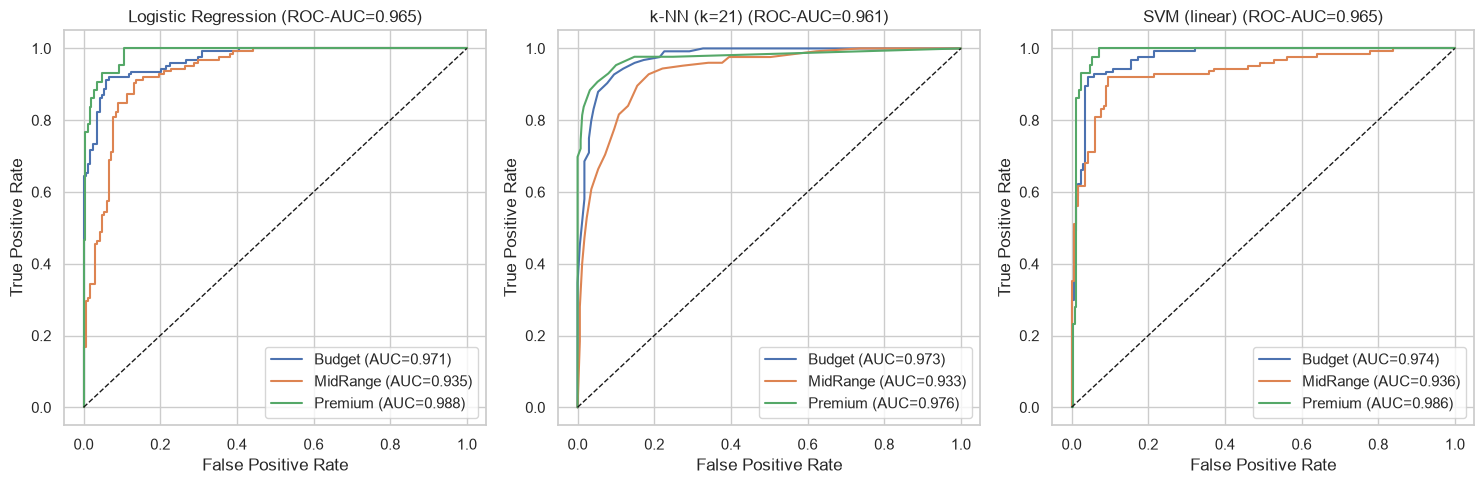

In [160]:
def plot_roc_multiclass(ax, y_true, y_proba, title, classes=CLASSES):
    for i, c in enumerate(classes):
        y_true_bin = (y_true == c).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, y_proba[:, i])
        auc_c = roc_auc_score(y_true_bin, y_proba[:, i])
        ax.plot(fpr, tpr, label=f'{c} (AUC={auc_c:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_roc_multiclass(axes[0], y_val_final, lr_val_proba, f"Logistic Regression (ROC-AUC={lr_val_metrics['ROC-AUC']:.3f})")
plot_roc_multiclass(axes[1], y_val_final, knn_val_proba, f"k-NN (k={best_k}) (ROC-AUC={knn_val_metrics['ROC-AUC']:.3f})")
plot_roc_multiclass(axes[2], y_val_final, svm_val_proba, f"SVM ({svm_best_kernel}) (ROC-AUC={svm_val_metrics['ROC-AUC']:.3f})")
plt.tight_layout()
plt.show()

In [161]:
roc_auc_compare = pd.DataFrame({
    'Logistic Regression': [lr_val_metrics['ROC-AUC']],
    f'k-NN (k={best_k})': [knn_val_metrics['ROC-AUC']],
    f'SVM ({svm_best_kernel})': [svm_val_metrics['ROC-AUC']],
}, index=['macro ROC-AUC (val)']).T
roc_auc_compare

,macro ROC-AUC (val)
Logistic Regression,0.964509
k-NN (k=21),0.960575
SVM (linear),0.965323


## 12. Comparative table of results

In [162]:
comparison_table = pd.DataFrame({
    'Logistic Regression': lr_val_metrics,
    f'k-NN (k={best_k})': knn_val_metrics,
    f'SVM ({svm_best_kernel}, C={svm_best_params['C']})': svm_val_metrics,
}).T[['Precision', 'Recall', 'F1-score', 'ROC-AUC']]

comparison_table

,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.870080,0.873187,0.871397,0.964509
k-NN (k=21),0.898040,0.827031,0.853126,0.960575
"SVM (linear, C=0.01)",0.912146,0.892188,0.901201,0.965323


## 13. Impact of feature scaling on k-NN and SVM

In [163]:
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k)
knn_unscaled.fit(X_train_unscaled, y_train_final)
knn_unscaled_metrics, _, _, _ = evaluate_classifier(knn_unscaled, X_val_unscaled, y_val_final)

svm_unscaled = CalibratedClassifierCV(SVC(kernel='linear', C=svm_best_params['C'], random_state=RANDOM_STATE), ensemble=False)
svm_unscaled.fit(X_train_unscaled, y_train_final)
svm_unscaled_metrics, _, _, _ = evaluate_classifier(svm_unscaled, X_val_unscaled, y_val_final)

scaling_impact = pd.DataFrame({
    'k-NN (scaled)': knn_val_metrics,
    'k-NN (unscaled)': knn_unscaled_metrics,
    'SVM (scaled)': svm_val_metrics,
    'SVM (unscaled)': svm_unscaled_metrics,
}).T[['Precision', 'Recall', 'F1-score', 'ROC-AUC']]
scaling_impact

,Precision,Recall,F1-score,ROC-AUC
k-NN (scaled),0.898040,0.827031,0.853126,0.960575
k-NN (unscaled),0.753155,0.634577,0.665753,0.862631
SVM (scaled),0.912146,0.892188,0.901201,0.965323
SVM (unscaled),0.879921,0.855265,0.866096,0.947290


## 14. Impact of model hyperparameters

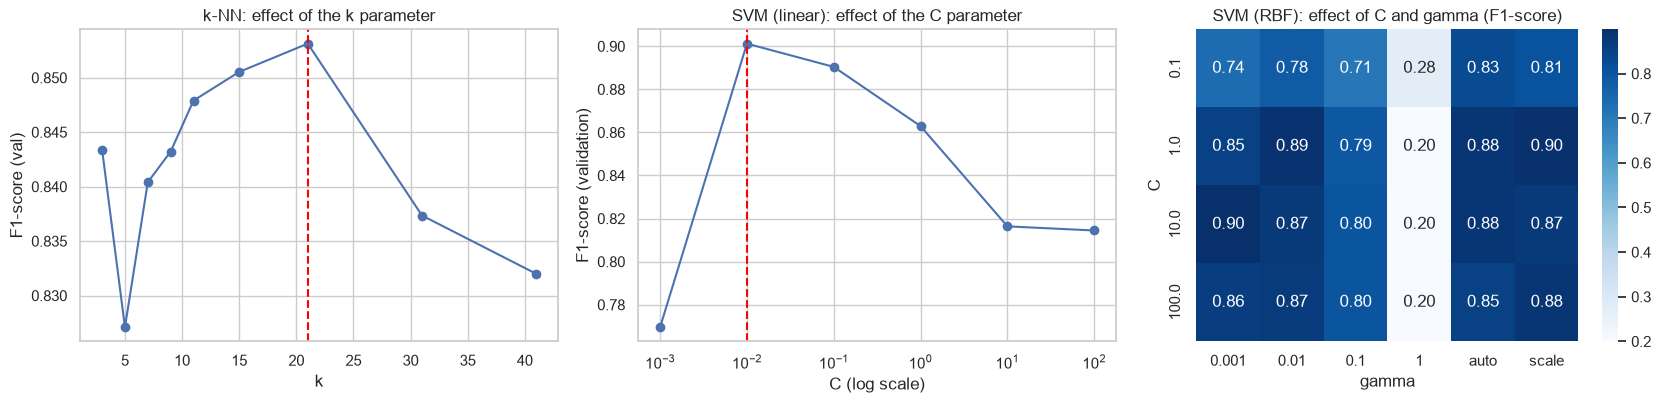

In [164]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

axes[0].plot(knn_results_df['k'], knn_results_df['F1-score'], marker='o')
axes[0].axvline(best_k, color='red', linestyle='--')
axes[0].set_xlabel('k')
axes[0].set_ylabel('F1-score (val)')
axes[0].set_title('k-NN: effect of the k parameter')

axes[1].plot(svm_linear_df['C'], svm_linear_df['F1-score'], marker='o')
axes[1].axvline(best_C_linear, color='red', linestyle='--')
axes[1].set_xscale('log')
axes[1].set_xlabel('C (log scale)')
axes[1].set_ylabel('F1-score (validation)')
axes[1].set_title('SVM (linear): effect of the C parameter')

pivot_f1 = svm_rbf_df.pivot_table(index='C', columns='gamma', values='F1-score', aggfunc='mean')
sns.heatmap(pivot_f1, annot=True, fmt='.2f', cmap='Blues', ax=axes[2])
axes[2].set_xlabel('gamma')
axes[2].set_ylabel('C')
axes[2].set_title('SVM (RBF): effect of C and gamma (F1-score)')

plt.tight_layout()
plt.show()

 ## 15. Selecting the most suitable model and hyperparameters

In [165]:
final_candidates = pd.DataFrame({
    'Logistic Regression': lr_val_metrics,
    f'k-NN (k={best_k})': knn_val_metrics,
    f'SVM ({svm_best_kernel}, {svm_best_params['C']})': svm_val_metrics,
}).T[['Precision', 'Recall', 'F1-score', 'ROC-AUC']]
display(final_candidates)

best_model_name = final_candidates['F1-score'].idxmax()
print(f"Selected: {best_model_name}")

,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.870080,0.873187,0.871397,0.964509
k-NN (k=21),0.898040,0.827031,0.853126,0.960575
"SVM (linear, 0.01)",0.912146,0.892188,0.901201,0.965323


Selected: SVM (linear, 0.01)


## 16. Retraining the selected model on train+val and final evaluation on test

In [166]:
X_trainval_raw = pd.concat([X_train, X_val], axis=0)
y_trainval_final = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

prep_final = build_preprocessor(X_trainval_raw)
X_trainval_final = apply_preprocessor(X_trainval_raw, prep_final).reset_index(drop=True)
X_test_final_2 = apply_preprocessor(X_test, prep_final).reset_index(drop=True)

final_model = CalibratedClassifierCV(SVC(kernel='linear', C=svm_best_params['C'], random_state=RANDOM_STATE), ensemble=False)
final_model.fit(X_trainval_final, y_trainval_final)

final_test_metrics, final_test_cm, final_test_pred, final_test_proba = evaluate_classifier(final_model, X_test_final_2, y_test_final)

print(f"Final model: {best_model_name}, retrained on train+val ({X_trainval_final.shape})")
print("Metrics on the test sample:")
pd.Series(final_test_metrics).to_frame('test')

Final model: SVM (linear, 0.01), retrained on train+val ((1168, 312))
Metrics on the test sample:


,test
Precision,0.902237
Recall,0.860889
F1-score,0.878001
ROC-AUC,0.975772
Accuracy,0.886986


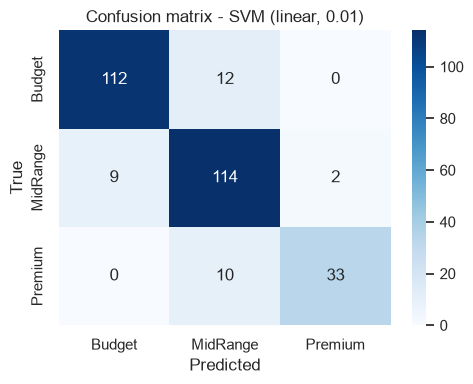

Classification report:
              precision    recall  f1-score   support

      Budget       0.93      0.90      0.91       124
    MidRange       0.84      0.91      0.87       125
     Premium       0.94      0.77      0.85        43

    accuracy                           0.89       292
   macro avg       0.90      0.86      0.88       292
weighted avg       0.89      0.89      0.89       292



In [167]:
plt.figure(figsize=(5, 4))
sns.heatmap(final_test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print("Classification report:")
print(classification_report(y_test_final, final_test_pred, labels=CLASSES, zero_division=0))